# 🏟️ Sports Vision Pipeline
## Universal Detection, Tracking, Segmentation & Player Identification

A sport-agnostic computer vision pipeline for:
- **Object Detection** — RF-DETR / YOLO (custom fine-tuned)
- **Player Tracking** — SAM2 real-time segmentation + persistent IDs
- **Team Classification** — SigLIP embeddings → UMAP → K-means (unsupervised)
- **Jersey OCR** — SmolVLM2 / PaddleOCR number recognition
- **Player Identification** — Temporal validation + roster lookup
- **Field/Court Mapping** — Keypoint homography → bird's-eye view

**Author:** Jaime Tellie (FallenSkywalker)  
**Architecture:** Modular — each component is a reusable class/function for integration into React apps via FastAPI.

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Configuration

All sport-specific settings live in a single config dict. Swap this to switch sports — the pipeline doesn't change.

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# SOURCE_VIDEO_DIRECTORY = HOME / "source"
# !yt-dlp -f "best[height<=1080]" -o "{SOURCE_VIDEO_DIRECTORY}/%(title)s.%(ext)s" "https://www.youtube.com/watch?v=S_NqfSLyQ7s"

## 1. Environment Setup

In [2]:
import os
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

# --- API Keys ---
# Uncomment for Colab:
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
# os.environ["ROBOFLOW_API_KEY"] = userdata.get("RUGBY_API_KEY")

# --- GPU Check ---
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

HOME = Path.cwd()
print(f"HOME: {HOME}")

Device: cuda
NVIDIA A100-SXM4-40GB, 40960 MiB
HOME: /content


In [3]:
# --- Install Dependencies ---
# Uncomment for fresh Colab:

!git clone https://github.com/Gy920/segment-anything-2-real-time.git
%cd {HOME}/segment-anything-2-real-time
!pip install -e . -q
!python setup.py build_ext --inplace
!(cd checkpoints && bash download_ckpts.sh)
%cd {HOME}

!pip install -q gdown inference-gpu
!pip install -q supervision==0.27.0
!pip install -q git+https://github.com/roboflow/sports.git@feat/basketball
!pip install -q transformers num2words
!pip install -q yt-dlp
!pip install trackers

os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

Cloning into 'segment-anything-2-real-time'...
remote: Enumerating objects: 406, done.
remote: Counting objects: 100% (93/93), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 406 (delta 65), reused 56 (delta 56), pack-reused 313 (from 2)
Receiving objects: 100% (406/406), 79.43 MiB | 53.12 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/segment-anything-2-real-time
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 7.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building editable for SAM-2 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error origina

In [4]:
# --- Core Imports ---
import cv2
import numpy as np
import torch
from tqdm import tqdm
from IPython.display import Video

from trackers import SORTTracker

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer,
)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

print("✅ Imports loaded")

ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


✅ Imports loaded


In [5]:
import sys

# Remove any existing sam2 from sys.modules so it reloads fresh
mods_to_remove = [k for k in sys.modules if k.startswith("sam2")]
for k in mods_to_remove:
  del sys.modules[k]

# Put the fork FIRST on sys.path
fork_path = str(HOME / "segment-anything-2-real-time")
if fork_path in sys.path:
  sys.path.remove(fork_path)
sys.path.insert(0, fork_path)

# Now import — should pick up the fork
from sam2.build_sam import build_sam2_camera_predictor
print(f"✅ Loaded from: {build_sam2_camera_predictor.__module__}")

✅ Loaded from: sam2.build_sam


## 2. Video Source

Point to your video(s). Supports single file or a directory of clips for multi-video team training.

In [6]:
# --- Download sample videos (basketball example) ---
# Uncomment to download NBA sample clips:
SOURCE_VIDEO_DIRECTORY = HOME / "source"
# !gdown -q https://drive.google.com/drive/folders/1eDJYqQ77Fytz15tKGdJCMeYSgmoQ-2-H -O {SOURCE_VIDEO_DIRECTORY} --folder

# --- Or point to your own videos ---
SOURCE_VIDEO_DIRECTORY = HOME / "source"
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "NZvsZAv1.mp4"

# For football POV:
# SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "Body Cam, Cable Guy und die Tore aus Sicht der FC-Spieler im Video 1.mp4"

# For referree POV:
# SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "NZvsZAv3.mp4"

print(f"📹 Source: {SOURCE_VIDEO_PATH}")
print(f"   Exists: {SOURCE_VIDEO_PATH.exists()}")

📹 Source: /content/source/NZvsZAv1.mp4
   Exists: True


In [15]:
@dataclass
class SportConfig:
    """Sport-agnostic configuration. Swap this to switch sports."""

    # --- Identity ---
    sport: str = "basketball"  # basketball, football, hockey, etc.

    # --- Detection Model ---
    detection_model_id: str = "basketball-player-detection-3-ycjdo/4"
    detection_confidence: float = 0.5
    detection_iou_threshold: float = 0.7

    # --- Class IDs (sport-specific) ---
    player_class_ids: List[int] = field(default_factory=lambda: [3, 4, 5, 6, 7])
    number_class_id: int = 2
    ball_class_id: int = 0
    referee_class_id: int = 8

    # --- OCR Model ---
    ocr_model_id: str = "basketball-jersey-numbers-ocr/3"
    ocr_prompt: str = "Read the number."

    # --- Keypoint Model (for field/court mapping) ---
    keypoint_model_id: Optional[str] = "basketball-court-detection-2/14"
    keypoint_confidence: float = 0.3
    keypoint_anchor_confidence: float = 0.5

    # --- Team Info ---
    team_names: Dict[int, str] = field(default_factory=lambda: {
        0: "Team A",
        1: "Team B"
    })
    team_colors: Dict[str, str] = field(default_factory=lambda: {
        "Team A": "#006BB6",
        "Team B": "#007A33"
    })
    team_rosters: Dict[str, Dict[str, str]] = field(default_factory=dict)

    # --- Tracking ---
    sam2_checkpoint: str = str(HOME / "segment-anything-2-real-time/checkpoints/sam2.1_hiera_large.pt")
    sam2_config: str = "configs/sam2.1/sam2.1_hiera_l.yaml"

    # --- Processing ---
    ocr_interval: int = 5  # Run OCR every N frames
    team_crop_scale: float = 0.4  # Scale factor for team classification crops
    consecutive_threshold: int = 3  # Frames needed to validate a number
    iou_match_threshold: float = 0.9  # IoS threshold for number-player matching


# ========================
# SPORT PRESETS
# ========================

BASKETBALL_CONFIG = SportConfig(
    sport="basketball",
    detection_model_id="basketball-player-detection-3-ycjdo/4",
    player_class_ids=[3, 4, 5, 6, 7],
    number_class_id=2,
    ball_class_id=0,
    referee_class_id=8,
    ocr_model_id="basketball-jersey-numbers-ocr/3",
    keypoint_model_id="basketball-court-detection-2/14",
    team_names={0: "Boston Celtics", 1: "New York Knicks"},
    team_colors={"Boston Celtics": "#007A33", "New York Knicks": "#006BB6"},
    team_rosters={
        "New York Knicks": {
            "55": "Hukporti", "1": "Payne", "0": "Wright", "11": "Brunson",
            "3": "Hart", "32": "Towns", "44": "Shamet", "25": "Bridges",
            "2": "McBride", "23": "Robinson", "8": "Anunoby", "4": "Dadiet",
            "5": "Achiuwa", "13": "Kolek"
        },
        "Boston Celtics": {
            "42": "Horford", "55": "Scheierman", "9": "White", "20": "Davison",
            "7": "Brown", "0": "Tatum", "27": "Walsh", "4": "Holiday",
            "8": "Porzingis", "40": "Kornet", "88": "Queta", "11": "Pritchard",
            "30": "Hauser", "12": "Craig", "26": "Tillman"
        }
    }
)

FOOTBALL_POV_CONFIG = SportConfig(
    sport="football",
    detection_model_id="football_pov_detection/1",
    detection_confidence=0.4,
    player_class_ids=[1, 2],  # Koln=1, Milan=2 (adjust if order differs)
    number_class_id=-1,  # Enable later with PaddleOCR
    ball_class_id=0,  # Ball
    referee_class_id=3,  # Referree
    ocr_model_id="basketball-jersey-numbers-ocr/3",
    keypoint_model_id=None,
    team_names={0: "FC Köln", 1: "AC Milan"},
    team_colors={"FC Köln": "#ED1C24", "AC Milan": "#000000"},
    team_rosters={
        "FC Köln": {str(i): name for i, name in enumerate([
            "Schwäbe", "Schmitz", "Kilian", "Hübers", "Olesen",
            "Skhiri", "Huseinbasic", "Ljubicic", "Kainz", "Thielmann",
            "Tigges", "Martel", "Lemperle", "Waldschmidt", "Downs",
            "Paciencia", "Adamyan", "Obuz", "Maina", "Uth",
            "Andersson", "Pedersen", "Schwirten", "Schaub", "Hector"
        ], 1)},
        "AC Milan": {str(i): name for i, name in enumerate([
            "Maignan", "Calabria", "Tomori", "Thiaw", "Hernández",
            "Bennacer", "Tonali", "Krunić", "Díaz", "Giroud",
            "Leão", "Rebić", "Origi", "Jović", "Saelemaekers",
            "De Ketelaere", "Messias", "Adli", "Pobega", "Gabbia",
            "Dest", "Tătărușanu", "Mirante", "Bakayoko", "Florenzi"
        ], 1)}
    }
)

REF_POV_CONFIG = SportConfig(
    sport="referee",
    detection_model_id="football-ref-pov/5", # football-ref-pov/1
    detection_confidence=0.2,
    player_class_ids=[1, 3],       # Juventus=1, Inter Milan=3
    number_class_id=2,             # Number=2
    ball_class_id=0,               # Ball=0
    referee_class_id=-1,           # No referee class in model
    ocr_model_id="basketball-jersey-numbers-ocr/3",
    keypoint_model_id=None,
    team_names={0: "Juventus", 1: "Inter Milan"},
    team_colors={"Juventus": "#000000", "Inter Milan": "#0068A8"},
    team_rosters={
        "Juventus": {
            "1": "Perin", "2": "Holm", "3": "Bremer",
            "4": "Gatti", "5": "Locatelli", "6": "Kelly",
            "7": "Conceição", "8": "Koopmeiners", "9": "Vlahović",
            "10": "Yildiz", "11": "Zhegrova", "13": "Boga",
            "14": "Milik", "15": "Kalulu", "16": "Di Gregorio",
            "17": "Adžić", "18": "Kostić", "19": "Thuram",
            "21": "Miretti", "22": "McKennie", "23": "Pinsoglio",
            "26": "Douglas Luiz", "27": "Cambiaso", "32": "Cabal",
            "37": "Savona", "51": "Mbangula",
        },
        "Inter Milan": {
            "1": "Sommer", "2": "Dumfries", "6": "De Vrij",
            "7": "Zielinski", "9": "Thuram", "10": "Lautaro",
            "12": "Di Gennaro", "13": "J. Martinez", "15": "Acerbi",
            "16": "Frattesi", "20": "Calhanoglu", "21": "Asllani",
            "22": "Mkhitaryan", "23": "Barella", "28": "Pavard",
            "30": "Carlos Augusto", "31": "Bisseck", "32": "Dimarco",
            "36": "Darmian", "95": "Bastoni", "99": "Taremi",
        },
    },
)

RUGBY_CONFIG = SportConfig(
    sport="rugby",
    detection_model_id="rugby_player_detection-9ezs6/5", # football-ref-pov/1
    detection_confidence=0.5,
    player_class_ids=[0, 3],       # Juventus=1, Inter Milan=3
    number_class_id=-1,             # Number=2
    ball_class_id=-1,               # Ball=0
    referee_class_id=2,           # No referee class in model
    ocr_model_id="basketball-jersey-numbers-ocr/3",
    keypoint_model_id=None,
    team_names={0: "Springboks", 1: "All Blacks"},
    team_colors={"Springboks": "#000000", "All Blacks": "#0068A8"},
    team_rosters={
        "Springboks": {
            "1": "Perin", "2": "Holm", "3": "Bremer",
            "4": "Gatti", "5": "Locatelli", "6": "Kelly",
            "7": "Conceição", "8": "Koopmeiners", "9": "Vlahović",
            "10": "Yildiz", "11": "Zhegrova", "13": "Boga",
            "14": "Milik", "15": "Kalulu", "16": "Di Gregorio",
            "17": "Adžić", "18": "Kostić", "19": "Thuram",
            "21": "Miretti", "22": "McKennie", "23": "Pinsoglio",
            "26": "Douglas Luiz", "27": "Cambiaso", "32": "Cabal",
            "37": "Savona", "51": "Mbangula",
        },
        "All Blacks": {
            "1": "Sommer", "2": "Dumfries", "6": "De Vrij",
            "7": "Zielinski", "9": "Thuram", "10": "Lautaro",
            "12": "Di Gennaro", "13": "J. Martinez", "15": "Acerbi",
            "16": "Frattesi", "20": "Calhanoglu", "21": "Asllani",
            "22": "Mkhitaryan", "23": "Barella", "28": "Pavard",
            "30": "Carlos Augusto", "31": "Bisseck", "32": "Dimarco",
            "36": "Darmian", "95": "Bastoni", "99": "Taremi",
        },
    },
)

# ========================
# SELECT ACTIVE CONFIG
# ========================
CONFIG = RUGBY_CONFIG
print(f"🏟️ Active sport: {CONFIG.sport}")

🏟️ Active sport: rugby


## 3. Core Pipeline Components

Each component is a **reusable class** — designed for extraction into a Python module for FastAPI/React integration.

In [16]:
# ============================================================
# 3a. DETECTOR — Wraps any Roboflow model (RF-DETR, YOLO, etc.)
# ============================================================

class SportDetector:
    """Sport-agnostic object detector using Roboflow Inference."""

    def __init__(self, config: SportConfig):
        self.config = config
        self.model = get_model(model_id=config.detection_model_id)
        print(f"✅ Loaded detection model: {config.detection_model_id} with classes: {self.model.class_names}")

    def detect(self, frame: np.ndarray) -> sv.Detections:
        """Run detection on a single frame."""
        result = self.model.infer(
            frame,
            confidence=self.config.detection_confidence,
            iou_threshold=self.config.detection_iou_threshold
        )[0]
        return sv.Detections.from_inference(result)

    def detect_players(self, frame: np.ndarray) -> sv.Detections:
        """Detect only player-class objects."""
        detections = self.detect(frame)
        return detections[np.isin(detections.class_id, self.config.player_class_ids)]

    def detect_numbers(self, frame: np.ndarray) -> sv.Detections:
        """Detect only jersey number regions."""
        if self.config.number_class_id < 0:
            return sv.Detections.empty()
        detections = self.detect(frame)
        return detections[detections.class_id == self.config.number_class_id]


detector = SportDetector(CONFIG)

✅ Loaded detection model: rugby_player_detection-9ezs6/5 with classes: ['all_black', 'fan', 'referee', 'springbok']


In [17]:
# ============================================================
# 3b. TRACKER — SAM2-based segmentation tracker
# ============================================================

class SAM2Tracker:
    """SAM2-based tracker with pixel-perfect masks and persistent IDs.

    Prompt with detection boxes on first frame, then propagate masks
    through subsequent frames automatically.
    """

    def __init__(self, config: SportConfig):
        self.config = config
        self.predictor = build_sam2_camera_predictor(
          config.sam2_config, config.sam2_checkpoint
        )
        self._prompted = False
        print(f"✅ Loaded SAM2 tracker: {config.sam2_checkpoint}")

    def prompt_first_frame(self, frame: np.ndarray, detections: sv.Detections) -> None:
        """Initialize tracking with detection boxes on the first frame."""
        if len(detections) == 0:
            raise ValueError("Need at least one detection to initialize tracking")

        if detections.tracker_id is None:
            detections.tracker_id = np.arange(1, len(detections) + 1)

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=np.asarray([xyxy], dtype=np.float32),
                )
        self._prompted = True

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        """Track objects in the next frame. Returns detections with masks."""
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)
        if masks.ndim == 2:
            masks = masks[None, ...]

        masks = np.array([
            sv.filter_segments_by_distance(mask, relative_distance=0.03, mode="edge")
            for mask in masks
        ])

        xyxy = sv.mask_to_xyxy(masks=masks)
        return sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)

    def reset(self) -> None:
        self._prompted = False

In [18]:
# ============================================================
# 3c. TEAM CLASSIFIER — Unsupervised jersey clustering
# ============================================================

class SportTeamClassifier:
    """Unsupervised team classification using SigLIP embeddings.

    Pipeline: crop centers → SigLIP embeddings → UMAP 3D → K-means (k=2).
    Works for any sport with two visually distinct teams.
    """

    def __init__(self, device: str = "cuda"):
        self.classifier = TeamClassifier(device=device)
        self._fitted = False

    def collect_training_crops(
        self,
        video_dir: Path,
        detector: SportDetector,
        stride: int = 30,
        crop_scale: float = 0.4
    ) -> List[np.ndarray]:
        """Collect jersey crops from all videos in a directory.

        Samples every `stride` frames, extracts center crops at `crop_scale`
        to focus on jersey color/texture.
        """
        crops = []
        video_files = sv.list_files_with_extensions(video_dir, extensions=["mp4", "avi", "mov"])

        for video_path in video_files:
            frame_gen = sv.get_video_frames_generator(source_path=video_path, stride=stride)
            for frame in tqdm(frame_gen, desc=f"Collecting crops: {Path(video_path).name}"):
                detections = detector.detect_players(frame)
                boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=crop_scale)
                for box in boxes:
                    crops.append(sv.crop_image(frame, box))

        print(f"✅ Collected {len(crops)} training crops from {len(video_files)} videos")
        return crops

    def fit(self, crops: List[np.ndarray]) -> None:
        """Train the team classifier on collected crops."""
        self.classifier.fit(crops)
        self._fitted = True
        print("✅ Team classifier trained")

    def predict(self, crops: List[np.ndarray]) -> np.ndarray:
        """Predict team IDs (0 or 1) for a list of crops."""
        if not self._fitted:
            raise RuntimeError("Call fit() before predict()")
        return np.array(self.classifier.predict(crops))

    def classify_frame(
        self, frame: np.ndarray, detections: sv.Detections, crop_scale: float = 0.4
    ) -> np.ndarray:
        """Classify all players in a single frame."""
        boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=crop_scale)
        crops = [sv.crop_image(frame, box) for box in boxes]
        return self.predict(crops)

    def visualize_teams(self, crops: List[np.ndarray], teams: np.ndarray) -> None:
        """Show grid of crops per team for validation."""
        for team_id in sorted(set(teams)):
            team_crops = [c for c, t in zip(crops, teams) if t == team_id]
            n = min(50, len(team_crops))
            cols = min(10, n)
            rows = (n + cols - 1) // cols
            print(f"\n--- Team {team_id} ({len(team_crops)} crops) ---")
            sv.plot_images_grid(images=team_crops[:n], grid_size=(rows, cols), size=(10, rows))

In [19]:
# ============================================================
# 3d. JERSEY OCR — Number recognition + temporal validation
# ============================================================

class JerseyOCR:
    """Jersey number recognition with temporal consensus validation.

    Uses a fine-tuned VLM (SmolVLM2) to read numbers from crops,
    then validates across frames using ConsecutiveValueTracker.
    """

    def __init__(self, config: SportConfig):
        self.config = config
        self.model = None
        self.validator = ConsecutiveValueTracker(n_consecutive=config.consecutive_threshold)

        if config.ocr_model_id:
            self.model = get_model(model_id=config.ocr_model_id)
            print(f"✅ Loaded OCR model: {config.ocr_model_id}")
        else:
            print("⚠️ No OCR model configured — jersey numbers disabled")

    def read_numbers(
        self, frame: np.ndarray, number_detections: sv.Detections
    ) -> List[str]:
        """Read jersey numbers from detected number regions."""
        if self.model is None or len(number_detections) == 0:
            return []

        frame_h, frame_w = frame.shape[:2]
        padded = sv.clip_boxes(
            sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10),
            (frame_w, frame_h)
        )
        crops = [
            sv.resize_image(sv.crop_image(frame, xyxy), resolution_wh=(224, 224))
            for xyxy in padded
        ]
        return [
            self.model.predict(crop, self.config.ocr_prompt)[0]
            for crop in crops
        ]

    def match_numbers_to_players(
        self,
        frame: np.ndarray,
        player_detections: sv.Detections,
        detector: SportDetector,
    ) -> None:
        """Detect numbers, match to players via IoS, update validator."""
        if self.model is None:
            return

        frame_h, frame_w = frame.shape[:2]
        number_dets = detector.detect_numbers(frame)
        if len(number_dets) == 0:
            return

        number_dets.mask = sv.xyxy_to_mask(
            boxes=number_dets.xyxy, resolution_wh=(frame_w, frame_h)
        )

        numbers = self.read_numbers(frame, number_dets)
        if not numbers:
            return

        # Match numbers to players using Intersection over Smaller Area
        iou = sv.mask_iou_batch(
            masks_true=player_detections.mask,
            masks_detection=number_dets.mask,
            overlap_metric=sv.OverlapMetric.IOS
        )

        pairs = self._coords_above_threshold(iou, self.config.iou_match_threshold)
        if not pairs:
            return

        player_idx, number_idx = zip(*pairs)
        player_ids = [i + 1 for i in player_idx]
        matched_numbers = [numbers[int(i)] for i in number_idx]
        self.validator.update(tracker_ids=player_ids, values=matched_numbers)

    def get_validated_numbers(self, tracker_ids: np.ndarray) -> np.ndarray:
        """Get temporally validated numbers for given tracker IDs."""
        return np.array(self.validator.get_validated(tracker_ids=tracker_ids))

    def resolve_names(
        self, numbers: np.ndarray, teams: np.ndarray, config: SportConfig
    ) -> List[str]:
        """Resolve jersey numbers to player names using roster lookup."""
        labels = []
        for number, team_id in zip(numbers, teams):
            team_name = config.team_names.get(int(team_id), "Unknown")
            roster = config.team_rosters.get(team_name, {})
            name = roster.get(str(number), "")
            label = f"#{number} {name}" if name else f"#{number}"
            labels.append(label)
        return labels

    @staticmethod
    def _coords_above_threshold(
        matrix: np.ndarray, threshold: float
    ) -> List[Tuple[int, int]]:
        rows, cols = np.where(matrix > threshold)
        pairs = list(zip(rows.tolist(), cols.tolist()))
        pairs.sort(key=lambda rc: matrix[rc[0], rc[1]], reverse=True)
        return pairs

    def reset(self) -> None:
        self.validator = ConsecutiveValueTracker(
            n_consecutive=self.config.consecutive_threshold
        )

## 4. Phase 1 — Detection & Segmentation

Single frame test → Full video with SAM2 masks.

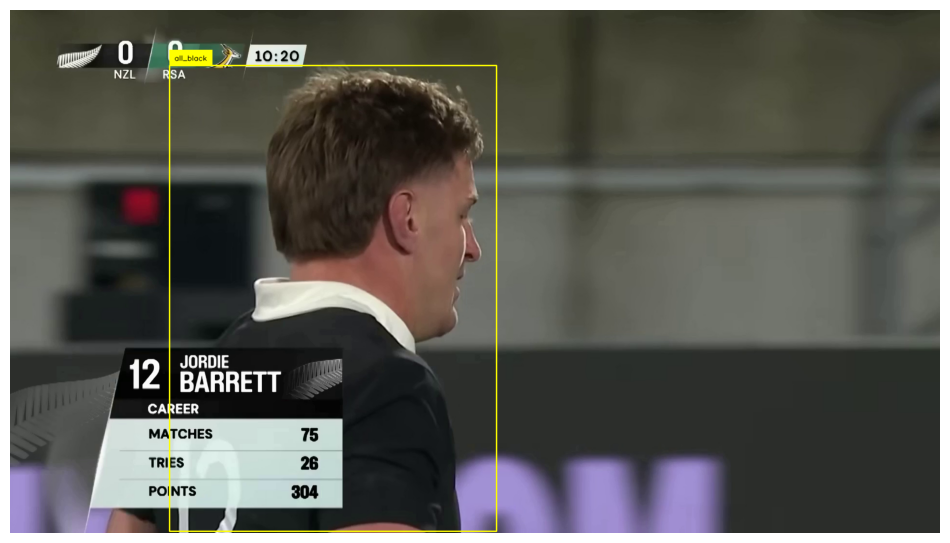

In [20]:
# --- 4a. Single Frame Detection ---

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_gen = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_gen)

# Full detection
detections = detector.detect_players(frame)
annotated = box_annotator.annotate(scene=frame.copy(), detections=detections)
annotated = label_annotator.annotate(scene=annotated, detections=detections)
sv.plot_image(annotated)

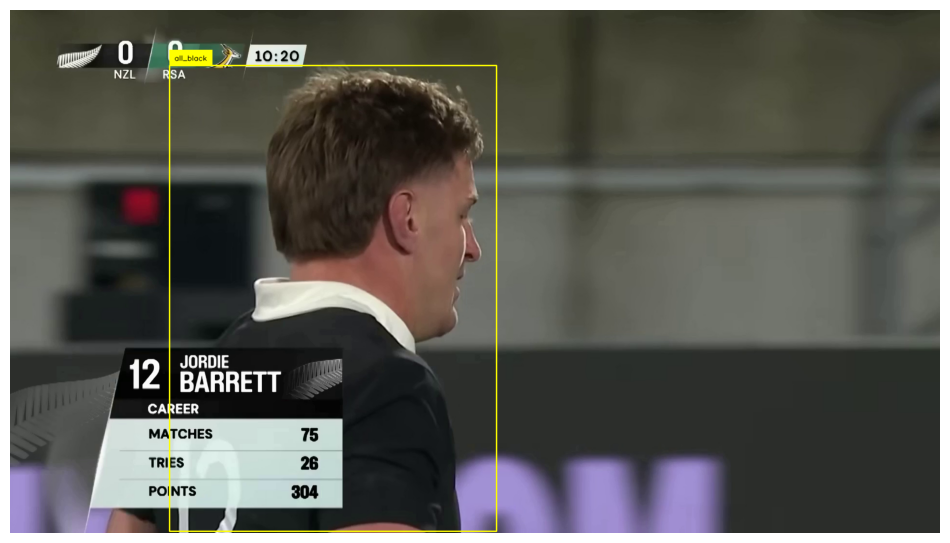

Detected 1 players


In [21]:
# --- 4b. Players Only ---

player_dets = detector.detect_players(frame)
annotated = box_annotator.annotate(scene=frame.copy(), detections=player_dets)
annotated = label_annotator.annotate(scene=annotated, detections=player_dets)
sv.plot_image(annotated)
print(f"Detected {len(player_dets)} players")

In [22]:
# --- 4c. Full Video — Tracking ---

TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-byte{SOURCE_VIDEO_PATH.suffix}"

# Initialize tracker
# tracker = sv.ByteTrack()
tracker = SORTTracker()

# Get first frame detections for SAM2 prompt
frame_gen = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
first_frame = next(frame_gen)
init_dets = detector.detect_players(first_frame)
init_dets.tracker_id = np.arange(1, len(init_dets) + 1)

# Annotators
mask_ann = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK, opacity=0.5)
box_ann = sv.BoxAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

def segment_callback(frame: np.ndarray, index: int) -> np.ndarray:
    dets = detector.detect_players(frame)
    # dets = tracker.update_with_detections(dets)
    dets = tracker.update(dets)
    out = frame.copy()
    # out = mask_ann.annotate(scene=out, detections=dets)
    out = box_ann.annotate(scene=out, detections=dets)
    out = label_annotator.annotate(scene=out, detections=dets)
    return out

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=segment_callback,
    show_progress=True
)

# Compress
COMPRESSED = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed.mp4"
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {COMPRESSED}
Video(COMPRESSED, embed=True, width=720)

Output hidden; open in https://colab.research.google.com to view.

In [23]:
# --- 4c. Full Video — SAM2 Segmentation + Tracking ---

TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-segmented{SOURCE_VIDEO_PATH.suffix}"

# Initialize tracker
tracker = SAM2Tracker(CONFIG)

# Get first frame detections for SAM2 prompt
frame_gen = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
first_frame = next(frame_gen)
init_dets = detector.detect_players(first_frame)
init_dets.tracker_id = np.arange(1, len(init_dets) + 1)

# Prompt SAM2
tracker.prompt_first_frame(first_frame, init_dets)

# Annotators
mask_ann = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK, opacity=0.5)
# box_ann = sv.BoxAnnotator(color=COLOR, color_lookup=sv.ColorLookup.TRACK, thickness=2)

def segment_callback(frame: np.ndarray, index: int) -> np.ndarray:
    dets = tracker.propagate(frame)
    out = frame.copy()
    out = mask_ann.annotate(scene=out, detections=dets)
    # out = box_ann.annotate(scene=out, detections=dets)
    return out

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=segment_callback,
    show_progress=True
)

# Compress
COMPRESSED = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed.mp4"
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {COMPRESSED}
Video(COMPRESSED, embed=True, width=720)

Output hidden; open in https://colab.research.google.com to view.

## 5. Phase 2 — Team Classification + Player Identification

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

...

✅ Collected 5892 training crops from 5 videos


Embedding extraction: 185it [00:18, 10.11it/s]


✅ Team classifier trained


Embedding extraction: 185it [00:18, 10.25it/s]



--- Team 0 (2905 crops) ---


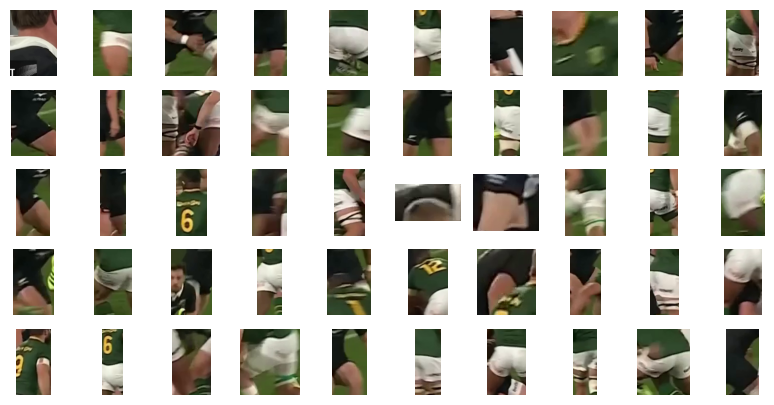


--- Team 1 (2987 crops) ---


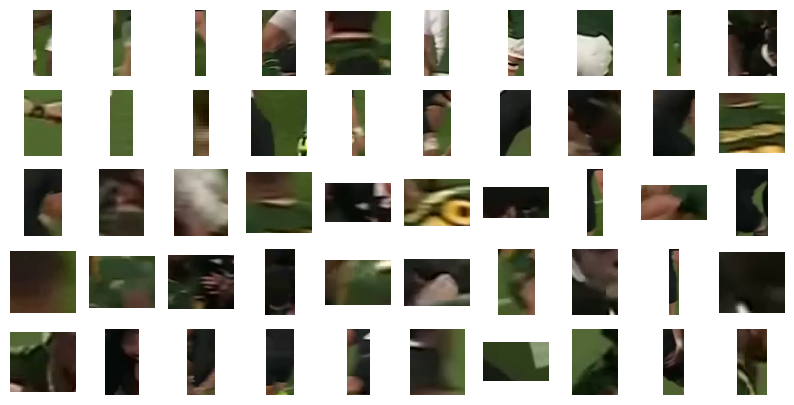

In [24]:
# --- 5a. Train Team Classifier ---

team_clf = SportTeamClassifier(device=DEVICE)

# Collect crops from all videos
training_crops = team_clf.collect_training_crops(
    video_dir=SOURCE_VIDEO_DIRECTORY,
    detector=detector,
    stride=10,
    crop_scale=CONFIG.team_crop_scale
)

# Train
team_clf.fit(training_crops)

# Validate
team_predictions = team_clf.predict(training_crops)
team_clf.visualize_teams(training_crops, team_predictions)

In [25]:
# ⚠️ After viewing the clusters above, set the correct mapping:
# The clustering assigns arbitrary 0/1 IDs — you must map them to actual teams.

# Option A:
# CONFIG.team_names = {0: "Boston Celtics", 1: "New York Knicks"}

# Option B (if clusters are swapped):
# CONFIG.team_names = {0: "New York Knicks", 1: "Boston Celtics"}

print(f"Team mapping: {CONFIG.team_names}")

Team mapping: {0: 'Springboks', 1: 'All Blacks'}


In [26]:
# --- 5b. Initialize OCR ---

jersey_ocr = JerseyOCR(CONFIG)

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

✅ Loaded OCR model: basketball-jersey-numbers-ocr/3


In [27]:
# --- 5c. Full Pipeline — Teams + Numbers + Names ---

TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-identified{SOURCE_VIDEO_PATH.suffix}"

# Storage for all frames (needed for final render pass)
frames_history = []
detections_history = []

# Validators
jersey_ocr.reset()
team_validator = ConsecutiveValueTracker(n_consecutive=1)

# First frame setup
frame_gen = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
first_frame = next(frame_gen)

init_dets = detector.detect(first_frame)
init_dets.tracker_id = np.arange(1, len(init_dets) + 1)

# Classify teams on first frame
TEAMS = team_clf.classify_frame(first_frame, init_dets, CONFIG.team_crop_scale)
team_validator.update(tracker_ids=init_dets.tracker_id, values=TEAMS)

# Initialize SAM2 tracker
tracker = SAM2Tracker(CONFIG)
tracker.prompt_first_frame(first_frame, init_dets)

# Process all frames
frame_gen = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
for idx, frame in tqdm(enumerate(frame_gen), desc="Processing"):
    player_dets = tracker.propagate(frame)
    frames_history.append(frame)
    detections_history.append(player_dets)

    # OCR at intervals
    if idx % CONFIG.ocr_interval == 0:
        jersey_ocr.match_numbers_to_players(frame, player_dets, detector)

print(f"✅ Processed {len(frames_history)} frames")

Embedding extraction: 1it [00:00, 62.47it/s]


✅ Loaded SAM2 tracker: /content/segment-anything-2-real-time/checkpoints/sam2.1_hiera_large.pt


Processing: 360it [00:32, 10.94it/s]

✅ Processed 360 frames


In [28]:
# --- 5d. Render Final Video ---

# Download fonts (for rich labels)
FONT_DIR = HOME / "fonts"
!gdown https://drive.google.com/drive/folders/1RBjpI5Xleb58lujeusxH0W5zYMMA4ytO -O {FONT_DIR} --folder

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

team_palette = sv.ColorPalette.from_hex([
    CONFIG.team_colors[CONFIG.team_names[0]],
    CONFIG.team_colors[CONFIG.team_names[1]]
])

team_mask_ann = sv.MaskAnnotator(
    color=team_palette, opacity=0.5, color_lookup=sv.ColorLookup.INDEX
)

font_path = str(FONT_DIR / "Staatliches-Regular.ttf")
team_label_ann = sv.RichLabelAnnotator(
    font_path=font_path,
    font_size=40,
    color=team_palette,
    text_color=sv.Color.WHITE,
    text_position=sv.Position.BOTTOM_CENTER,
    text_offset=(0, 10),
    color_lookup=sv.ColorLookup.INDEX
)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame, dets in tqdm(zip(frames_history, detections_history), desc="Rendering"):
        dets = dets[dets.area > 100]

        teams = team_validator.get_validated(tracker_ids=dets.tracker_id)
        teams = np.array(teams).astype(int)
        numbers = jersey_ocr.get_validated_numbers(dets.tracker_id)
        labels = jersey_ocr.resolve_names(numbers, teams, CONFIG)

        out = frame.copy()
        out = team_mask_ann.annotate(scene=out, detections=dets, custom_color_lookup=teams)
        out = team_label_ann.annotate(scene=out, detections=dets, labels=labels, custom_color_lookup=teams)
        sink.write_frame(out)

# Compress and display
COMPRESSED = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed.mp4"
!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {COMPRESSED}
Video(COMPRESSED, embed=True, width=720)

Output hidden; open in https://colab.research.google.com to view.

## 6. Summary & Next Steps

### What we built:
- ✅ **Sport-agnostic config** — swap `SportConfig` presets to switch sports
- ✅ **Detection** — `SportDetector` wraps any Roboflow model (RF-DETR, YOLO)
- ✅ **Segmentation + Tracking** — `SAM2Tracker` with pixel-perfect masks
- ✅ **Team Classification** — `SportTeamClassifier` (SigLIP → UMAP → K-means)
- ✅ **Jersey OCR** — `JerseyOCR` with temporal validation + roster lookup

### Phase 3 (upcoming):
- Field/court mapping via keypoint homography
- Movement analytics (heatmaps, speed, distance)
- Event detection (shots, goals, passes)
- Sports-skills data integration (live stats overlay)

### Python Module Extraction:
All classes (`SportDetector`, `SAM2Tracker`, `SportTeamClassifier`, `JerseyOCR`) are
designed for direct extraction into a Python package:

```
sports_vision/
├── __init__.py
├── config.py          # SportConfig + presets
├── detector.py        # SportDetector
├── tracker.py         # SAM2Tracker
├── team_classifier.py # SportTeamClassifier
├── jersey_ocr.py      # JerseyOCR
├── api.py             # FastAPI endpoints
└── cli.py             # CLI runner
```

This maps directly to a FastAPI service for React frontend integration.